##### AntiSpoof Model 

In [ ]:
#loading libraries 
import os
import shutil
import random 
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from PIL import Image
from matplotlib.pylab import angle

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

##### Model Configuration

In [17]:
#configuration for Model training 

#path to your LCC FASD dataset folder
SPOOF_DATA_ROOT = r'..\data\spoof_data\LCC_FASD'

#model and outputs paths
TRAIN_DIR  = os.path.join(SPOOF_DATA_ROOT, 'LCC_FASD_training')
VAL_DIR    = os.path.join(SPOOF_DATA_ROOT, 'LCC_FASD_development')
TEST_DIR   = os.path.join(SPOOF_DATA_ROOT, 'LCC_FASD_evaluation')

MODEL_DIR  = r'..\models'
OUTPUT_DIR = r'..\output'
MODEL_PATH = os.path.join(MODEL_DIR, 'spoof_model.keras')

IMAGE_SIZE  = (128, 128)
IMAGE_SHAPE = (128, 128, 3)

EPOCHS     = 30
BATCH_SIZE = 32
LR         = 1e-3
THRESHOLD  = 0.7
PATIENCE   = 10
REAL_LABEL  = 1
SPOOF_LABEL = 0
RETRAIN = False


os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


##### Downloading dataset

In [ ]:

PROJECT_DATA_DIR = os.path.join(
    os.path.dirname(os.path.abspath(__file__)),
    "..", "data", "spoof_data"
)

# Download dataset from Kaggle
print("Downloading LCC FASD dataset from Kaggle...")
kaggle_path = kagglehub.dataset_download("faber24/lcc-fasd")

print(f"\nDownloaded to Kaggle cache: {kaggle_path}")


# Copy into project data/spoof_data/ folder
print(f"\nCopying into project folder: {PROJECT_DATA_DIR}")

if os.path.exists(PROJECT_DATA_DIR):
    print("  data/spoof_data/ already exists — overwriting...")
    shutil.rmtree(PROJECT_DATA_DIR)

shutil.copytree(kaggle_path, PROJECT_DATA_DIR)


print("\n" + "="*55)
print("LCC FASD dataset ready!")
print(f"Location: {PROJECT_DATA_DIR}")
print("="*55)

print("\nFolder contents:")
for item in sorted(os.listdir(PROJECT_DATA_DIR)):
    full = os.path.join(PROJECT_DATA_DIR, item)
    if os.path.isdir(full):
        count = sum(len(f) for _, _, f in os.walk(full))
        print(f"  [{item}/]  —  {count} files")
    else:
        size = os.path.getsize(full) / 1024
        print(f"  {item}  —  {size:.1f} KB")

print(f'\nPaste this path into spoof_config.py:')
print(f'SPOOF_DATA_ROOT = r"{PROJECT_DATA_DIR}"')

##### Loading Dataset

In [18]:
#Loading dataset 
def load_samples(folder, balance=False):

    real_dir = os.path.join(folder, 'real')
    spoof_dir = os.path.join(folder, 'spoof')

    real_samples = []
    spoof_samples = []

    # Load real samples
    for fname in os.listdir(real_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            real_samples.append((os.path.join(real_dir, fname), REAL_LABEL))
        
    # Load spoof samples
    for fname in os.listdir(spoof_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            spoof_samples.append((os.path.join(spoof_dir, fname), SPOOF_LABEL))

    if balance:
        random.seed(42)
        spoof_samples = random.sample(spoof_samples, len(real_samples))
        print(f'Balanced dataset: {len(real_samples)} real and {len(spoof_samples)} spoof samples')
    
    samples = real_samples + spoof_samples
    random.shuffle(samples)

    real_count = sum(1 for _, label in samples if label == REAL_LABEL)
    spoof_count = sum(1 for _, label in samples if label == SPOOF_LABEL)
    print(f'Loaded {len(samples)} samples: {real_count} real and {spoof_count} spoof')
    return samples

print('Training set (balanced):')
train_samples = load_samples(TRAIN_DIR, balance=False)

print('Validation set:')
val_samples = load_samples(VAL_DIR, balance=False)

print('Test set:')
test_samples = load_samples(TEST_DIR, balance=False)


Training set (balanced):
Loaded 8299 samples: 1223 real and 7076 spoof
Validation set:
Loaded 2948 samples: 405 real and 2543 spoof
Test set:
Loaded 7580 samples: 314 real and 7266 spoof


##### Preview Sample Images

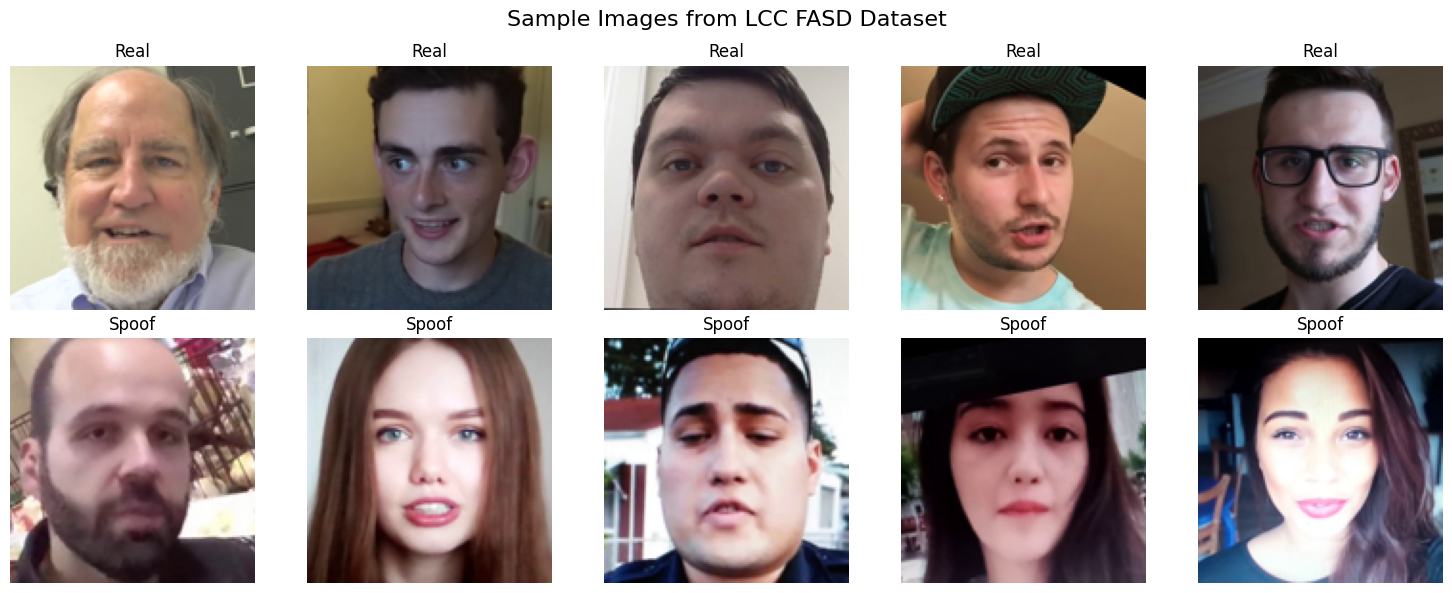

In [19]:
#show sample images side by side
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from LCC FASD Dataset', fontsize=16)

real_preview = [ s for s in train_samples if s[1] == REAL_LABEL][:5]
spoof_preview = [ s for s in train_samples if s[1] == SPOOF_LABEL][:5]

for i, (path, _) in enumerate(real_preview):
    img = Image.open(path).convert('RGB').resize(IMAGE_SIZE)
    axes[0, i].imshow(img)
    axes[0, i].set_title('Real')
    axes[0, i].axis('off')

for i, (path, _) in enumerate(spoof_preview):
    img = Image.open(path).convert('RGB').resize(IMAGE_SIZE)
    axes[1, i].imshow(img)
    axes[1, i].set_title('Spoof')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


##### Data pipeline 

In [20]:
def preprocess_image(path, augment=False):
    #loading image, resizing and normalising images
    img = Image.open(path).convert('RGB').resize(IMAGE_SIZE)
    img = np.array(img, dtype=np.float32) / 255.0

    if augment:
        # horizontal flip
        if random.random() < 0.5:
            img = np.fliplr(img)

        # brightness adjustment
        factor = random.uniform(0.9, 1.1)
        img    = np.clip(img * factor, 0, 1)

        # rotation using PIL instead of scipy
        angle    = random.uniform(-10, 10)
        img_pil  = Image.fromarray((img * 255).astype(np.uint8))
        img_pil  = img_pil.rotate(angle, resample=Image.BILINEAR)
        img      = np.array(img_pil, dtype=np.float32) / 255.0

    # ensure correct shape and dtype
    img = img.astype(np.float32)
    return img

def build_tf_dataset(samples, augment=False, batch_size=BATCH_SIZE, shuffle=True):

    paths = [s[0] for s in samples]
    labels = [s[1] for s in samples]

    def load_fn(path, label):
        img = tf.py_function(
            lambda p: preprocess_image(p.numpy().decode('utf-8'), augment=augment),
            [path], tf.float32
        )
        img.set_shape(IMAGE_SHAPE)
        return img, tf.cast(label, tf.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset 

train_ds = build_tf_dataset(train_samples, augment=True)
val_ds = build_tf_dataset(val_samples, augment=False)
test_ds = build_tf_dataset(test_samples, augment=False)


##### Building Model Architecture 

In [21]:
#load MobileNetV2 model
backbone = MobileNetV2(
    include_top=False, 
    weights='imagenet', 
    input_shape=IMAGE_SHAPE,
    pooling='avg'
)

#freeze backbone layers
backbone.trainable = False

#unfreezing last few layers for fine-tuning
for layer in backbone.layers[-6:]:
    layer.trainable = True

#building classifier on top of backbone
inputs = keras.Input(shape=IMAGE_SHAPE)
x = backbone(inputs, training=False)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x= layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#summary of model architecture and trainable parameters
trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
total     = sum(np.prod(w.shape) for w in model.weights)
print('Model built')
print(f'  Backbone    : MobileNetV2 (ImageNet pretrained)')
print(f'  Trainable   : {trainable:,} / {total:,} params ({100*trainable/total:.1f}%)')

Model built
  Backbone    : MobileNetV2 (ImageNet pretrained)
  Trainable   : 884,353 / 2,422,593 params (36.5%)


##### Training the model 

In [22]:
if RETRAIN or not os.path.exists(MODEL_PATH):

    callbacks = [
        #saving best model automatically 
        ModelCheckpoint(
            filepath=MODEL_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1 
        ),

        #early stopping to prevent overfitting
        EarlyStopping(
            monitor='val_accuracy',
            patience=PATIENCE,
            mode='max',
            verbose=1,
            restore_best_weights=True
        ),

        #reduce learning rate if validation accuracy plateaus
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=5,
            mode='max',
            verbose=1
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    print('Training complete. Best model saved to:', MODEL_PATH)
else:
    print('Loading existing model from:', MODEL_PATH)
    model = keras.models.load_model(MODEL_PATH)
    history = None
    

Loading existing model from: ..\models\spoof_model.keras


##### Plotting Training History 

In [23]:
if history is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
    ax1.set_title('Accuracy over epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val',   linewidth=2)
    ax2.set_title('Loss over epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'spoof_training_history.png'), dpi=150)
    plt.show()
    print('Saved: spoof_training_history.png')
else:
    print('No training history — model was loaded from file')

No training history — model was loaded from file


##### Evaluating model with test set 

In [24]:
print('Evaluating on test set: ')

real_test    = [s for s in test_samples if s[1] == REAL_LABEL]
spoof_test   = [s for s in test_samples if s[1] == SPOOF_LABEL]
random.seed(42)
spoof_test   = random.sample(spoof_test, len(real_test))
balanced_test = real_test + spoof_test
random.shuffle(balanced_test)

print(f'Original test  : {len(test_samples)} samples '
      f'({sum(1 for _,l in test_samples if l==REAL_LABEL)} real, '
      f'{sum(1 for _,l in test_samples if l==SPOOF_LABEL)} spoof)')
print(f'Balanced test  : {len(balanced_test)} samples '
      f'({len(real_test)} real, {len(spoof_test)} spoof)')

# build balanced test dataset
balanced_test_ds = build_tf_dataset(balanced_test, augment=False)

THRESHOLD = 0.5
#predicting probabilities and applying threshold to get binary predictions
all_probs = model.predict(test_ds, verbose=1).flatten()
all_preds = (all_probs >= THRESHOLD).astype(float)
all_labels = np.array([s[1] for s in test_samples], dtype=float)

#calculating overall accuracy, as well as separate accuracies for real and spoof classes
accuracy = (all_preds == all_labels).mean()
real_mask = all_labels == REAL_LABEL
spoof_mask = all_labels == SPOOF_LABEL
real_acc = (all_preds[real_mask] == all_labels[real_mask]).mean()
spoof_acc = (all_preds[spoof_mask] == all_labels[spoof_mask]).mean()

#printing results and classification report
print(f'\nResults:')
print(f'  Overall accuracy   : {accuracy:.4f}')
print(f'  Real face accuracy : {real_acc:.4f}')
print(f'  Spoof accuracy     : {spoof_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['Spoof', 'Real']))

Evaluating on test set: 
Original test  : 7580 samples (314 real, 7266 spoof)
Balanced test  : 628 samples (314 real, 314 spoof)
237/237 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step

Results:
  Overall accuracy   : 0.9558
  Real face accuracy : 0.4363
  Spoof accuracy     : 0.9783

Classification Report:
              precision    recall  f1-score   support

       Spoof       0.98      0.98      0.98      7266
        Real       0.46      0.44      0.45       314

    accuracy                           0.96      7580
   macro avg       0.72      0.71      0.71      7580
weighted avg       0.95      0.96      0.96      7580



##### ROC Curve

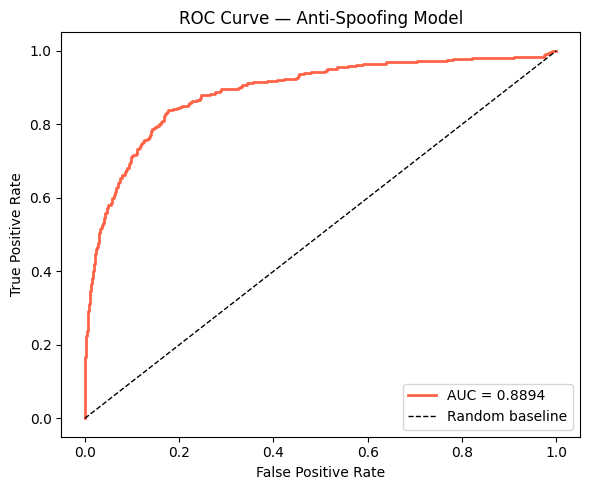

AUC: 0.8894
Saved: spoof_roc.png


In [25]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, color='tomato', label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Anti-Spoofing Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spoof_roc.png'), dpi=150)
plt.show()
print(f'AUC: {auc_score:.4f}')
print('Saved: spoof_roc.png')

##### Confusion Matrix 

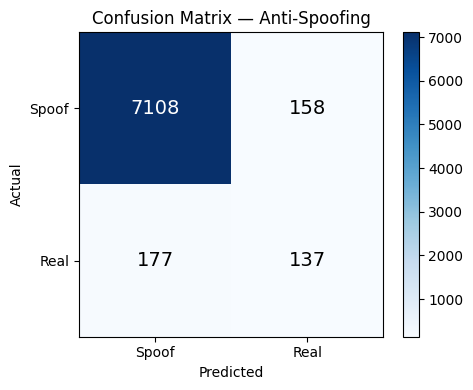

Saved: spoof_confusion_matrix.png


In [26]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1], ['Spoof', 'Real'])
plt.yticks([0, 1], ['Spoof', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Anti-Spoofing')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spoof_confusion_matrix.png'), dpi=150)
plt.show()
print('Saved: spoof_confusion_matrix.png')

##### Model Summary

In [27]:
print('=' * 50)
print('Anti-Spoofing Results Summary')
print('=' * 50)
print(f'  Dataset     : LCC FASD')
print(f'  Backbone    : ResNet50 (ImageNet pretrained)')
print(f'  AUC         : {auc_score:.4f}')
print(f'  Overall Acc : {accuracy:.4f}')
print(f'  Real Acc    : {real_acc:.4f}')
print(f'  Spoof Acc   : {spoof_acc:.4f}')
print(f'  Model saved : {MODEL_PATH}')
print('=' * 50)

Anti-Spoofing Results Summary
  Dataset     : LCC FASD
  Backbone    : ResNet50 (ImageNet pretrained)
  AUC         : 0.8894
  Overall Acc : 0.9558
  Real Acc    : 0.4363
  Spoof Acc   : 0.9783
  Model saved : ..\models\spoof_model.keras
